# Model Evaluation

## Objective

The objective of this notebook is to evaluate the performance of the tuned Gradient Boosting Regressor on unseen test data.

The model is evaluated using regression metrics and visualizations to understand prediction accuracy and error distribution.

In [1]:
# ==========================
# Import Libraries
# ==========================

import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# ==========================
# Loading Model and Data
# ==========================

model = joblib.load("../models/tuned_gradient_boosting.pkl")

X_test = joblib.load("../models/X_test_encoded.pkl")

y_test = joblib.load("../models/y_test.pkl")

In [3]:
# ==========================
# Predictions
# ==========================

predictions = model.predict(X_test)

In [4]:
# ==========================
# Evaluation Metrics
# ==========================

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

In [5]:
# Display Evaluation Metrics

metrics = pd.DataFrame({
    'Metric': ["MAE", "MSE", "RMSE", "R² Score"],
    'Value': [mae, mse, rmse, r2]
})

metrics

,Metric,Value
0,MAE,1.554437e+04
1,MSE,6.540785e+08
2,RMSE,2.557496e+04
3,R² Score,9.147261e-01


In [6]:
# Save Evaluation Metrics to csv

metrics.to_csv(
    "../reports/results/final_model_metrics.csv",
    index=False
)

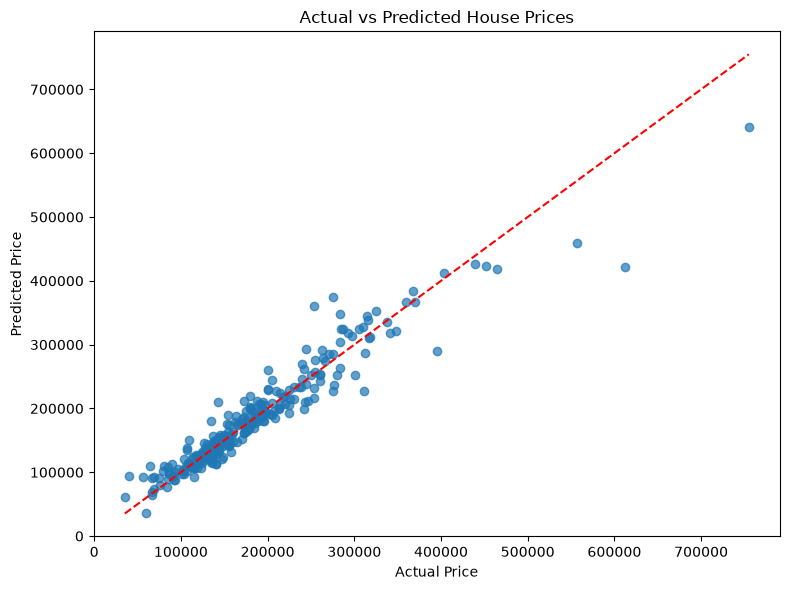

In [7]:
# ==========================
# Actual vs Predicted
# ==========================

plt.figure(figsize = (8, 6))

plt.scatter(y_test, predictions, alpha = 0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color = 'red',
    linestyle = '--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.tight_layout()

plt.savefig(
    "../reports/figures/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
# ==========================
# Residual Analysis
# ==========================

residuals = y_test - predictions

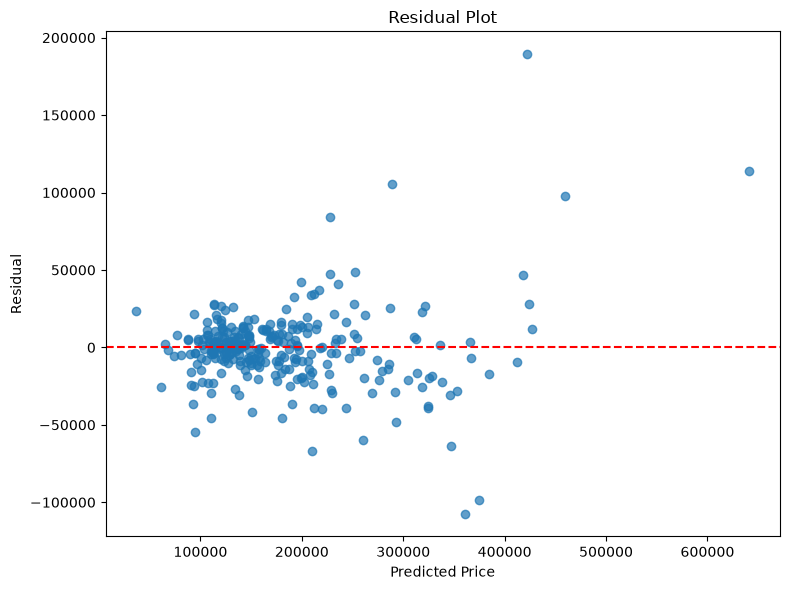

In [9]:
plt.figure(figsize = (8, 6))

plt.scatter(predictions, residuals, alpha = 0.7)

plt.axhline(y = 0, color = 'red', linestyle = '--')

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.tight_layout()

plt.savefig(
    "../reports/figures/residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

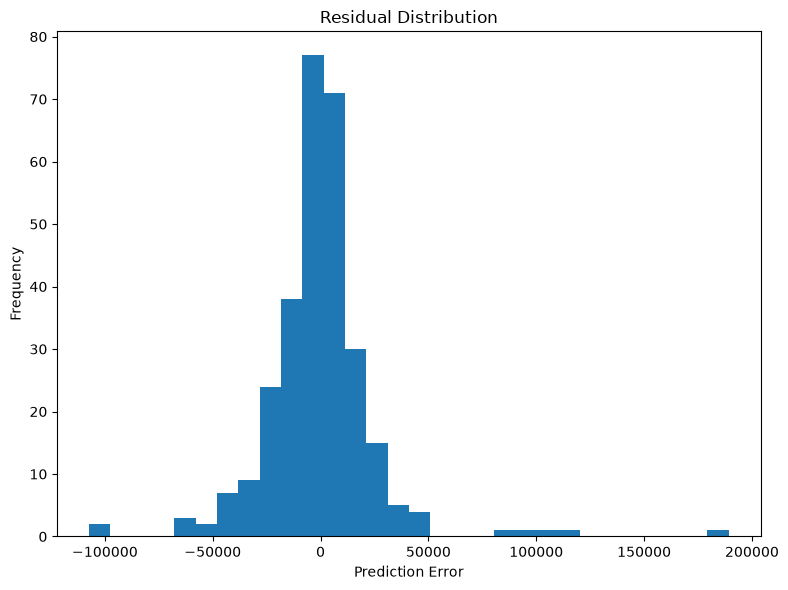

In [10]:
# ==========================
# Error Distribution
# ==========================

plt.figure(figsize = (8, 6))

plt.hist(residuals, bins = 30)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.tight_layout()

plt.savefig(
    "../reports/figures/residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
# ==========================
# Error Statistics
# ==========================

error_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions,
    'Residual': residuals,
    'Absolute Error': np.abs(residuals)
})

In [12]:
error_df.head()

,Actual,Predicted,Residual,Absolute Error
892,154500,142238.913452,12261.086548,12261.086548
1105,325000,353070.889247,-28070.889247,28070.889247
413,115000,109517.689314,5482.310686,5482.310686
522,159000,159478.235851,-478.235851,478.235851
1036,315500,337906.492572,-22406.492572,22406.492572


In [13]:
# Largest Errors

error_df.sort_values(
    by = 'Absolute Error',
    ascending = False
).head(10)

,Actual,Predicted,Residual,Absolute Error
898,611657,422412.082246,189244.917754,189244.917754
691,755000,641316.588534,113683.411466,113683.411466
581,253293,360568.277170,-107275.277170,107275.277170
774,395000,289296.969050,105703.030950,105703.030950
261,276000,374479.042498,-98479.042498,98479.042498
1046,556581,459050.842510,97530.157490,97530.157490
218,311500,227455.050991,84044.949009,84044.949009
588,143000,210132.116419,-67132.116419,67132.116419
332,284000,347486.141995,-63486.141995,63486.141995
1173,200500,260571.492233,-60071.492233,60071.492233


In [14]:
# ==========================
# Save Predictions
# ==========================

predictions_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': predictions,
    'Residual': residuals
})

predictions_df.to_csv(
    "../reports/results/predictions.csv",
    index=False
)

# Conclusion

The tuned Gradient Boosting Regressor demonstrated strong predictive performance on the test dataset.

The evaluation metrics and visualizations indicate that the model captures the relationship between housing features and sale prices effectively, with an R² score above 0.91.

Residual analysis suggests that prediction errors are centered around zero with no major systematic bias, indicating good generalization performance.